In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

### Import the training data

In [3]:
data = np.load("menu-match.npz")

# The training data is a 480 × 48 × 48 × 3 tensor, 
# meaning 480 images, each image is 48 × 48 pixels, with 3 color channels (RGB).

##### In short, y is the label ('a', 'i', 's')
##### In short, x is the image for food

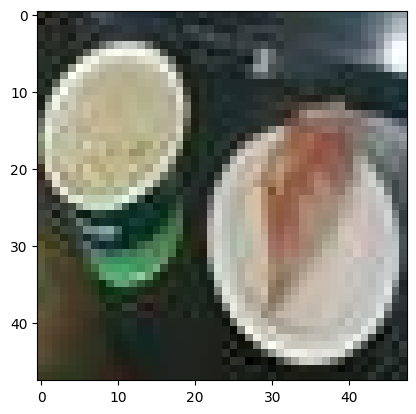

In [4]:
plt.imshow(data['X_test'][30])

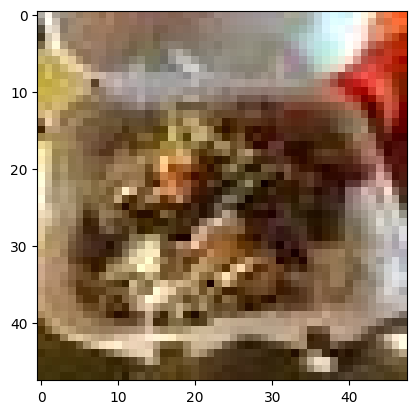

In [5]:
plt.imshow(data['X_train'][30])

In [6]:
data['X_train'].shape
# 480 training images, each 48×48 pixels with 3 RGB channels.

(480, 48, 48, 3)

In [7]:
data['X_test'].shape
# 166 test images, each 48×48 pixels with 3 RGB channels.

(166, 48, 48, 3)

In [8]:
data['y_train'].shape
# 480 training labels, one label per training image.

(480,)

In [9]:
data['y_test'].shape

(166,)

In [10]:
data['y_test'][0]

np.str_('a')

### Dataloader --> shuffle and then split into mini-batches
### train on small chunks instead of all 480 at once 

In [11]:
# 1) load data
data = np.load("menu-match.npz")
X = data["X_train"]   
y = data["y_train"]
X_TEST = data['X_test']
Y_TEST = data['y_test']

# data['X_train'].shape is (480, 48, 48, 3)

# 2) convert to torch + fix shape to channels-first for CNN
# converts NumPy → float tensor and reoder axes from NHWC to NCHW
# make it ready to put into 'Conv2d'(the learning layer). It needs num of image, channels, hieght width
X_t = torch.tensor(X).float().permute(0, 3, 1, 2)
X_test_t = torch.tensor(X_TEST).float().permute(0, 3, 1, 2)

# project version sample nvm 
# 3) convert string labels -> integer class IDs
# y: np array of strings like ["a","i","s", ...]
# classes = sorted(set(y))     # set remove duplications & sorted them in fixed order
# class_to_idx = {c:i for i,c in enumerate(classes)}   # Python function that adds an index to each item in the list.
# {'a': 0, 'i': 1, 's': 2}
# use the dict to convert each sample into according numbers
# y_t = torch.tensor([class_to_idx[c] for c in y], dtype=torch.long)       
# use the dict to convert each sample into according numbers
# y_test_t = torch.tensor([class_to_idx[c] for c in Y_TEST], dtype=torch.long) 

# 3) convert string lables -> A or not A labels
# if it is Asian, the label is 1
# if not, the label is 0
y_t = torch.tensor((y == "a").astype("int64"))       
y_test_t = torch.tensor((Y_TEST == "a").astype("int64"))   

### Dataset & Dataloader (shuffle + mini-batch)

In [12]:
batch_size = 64

# combine the x and y data
train_data = TensorDataset(X_t, y_t)
test_data  = TensorDataset(X_test_t, y_test_t)

# shuffle for better training
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# keep test order stable for clean, consistent evaluation
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

intput: (480, 48, 48, 3)

### Define the model(CNN), loss function, and optimizer

In [13]:
# 1) model
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),    # 3 represents the input channels (z-axis)
    nn.BatchNorm2d(16),                            # 16 represents the output channels (number of filters)
                                                   # kernel_size determine the filter size
    nn.ReLU(),                                     # activation function
    nn.MaxPool2d(2),                               # keeps the maximum value in each small window
                                                   # model more robust to small shifts

    nn.Conv2d(16, 32, kernel_size=3, padding=1),   # the input channels from previous layer
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),       

    nn.Flatten(),                              
    nn.Linear(32 * 12 * 12, 2)                     # calculate it from 48. 2 represents the output size
                                                   # btw can use nn.LazyLinear(2) to calculate it automatically 
)                                                  # use 2 here b/c it's asking 'A' or 'NOT A'

# 2) loss (for 3-class classification)
# many possibilities, but only one output is on
# use this loss func
loss_func = nn.CrossEntropyLoss()

# 3) optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Training Loop

In [14]:
for epoch in range(30):   # look at the train_loader for 30 times 
    # --- training ---
    model.train()                         # change to training mode
    total_loss, correct, n = 0.0, 0, 0    # initalize the total_loss, sample number(n), 
                                          # and correct sample num(correct)

    for X_batch, y_batch in train_loader:   # take the x and y data from the train_loader
        # forward               
        logits = model(X_batch)             # put the X_batch into the CNN and get the predicted output                
        loss = loss_func(logits, y_batch)   # calculate the error between prediction and true label   

        # backward
        optimizer.zero_grad()        # reset the previous GD to zero
        loss.backward()              # do the backprop
        optimizer.step()             # use GD from backprop to update the weights

        # stats
        total_loss += loss.item() * len(y_batch)   
        pred = logits.argmax(dim=1)            
        correct += (pred == y_batch).sum().item()
        n += len(y_batch)

    # --- evaluation ---
    model.eval()     # eval mode
    with torch.no_grad():   # don't calculate the GD or do the backprop
        test_logits = model(X_test_t)       
        test_pred = test_logits.argmax(dim=1)  # argmax(dim=1) find the max number in this row 
        test_acc = (test_pred == y_test_t).float().mean()  # calculate the accuracy
                                                           # transform T/F into 1/0 and then calculate mean

    print(f"Epoch {epoch+1:2d}/30 "
          f"loss={total_loss/n:.4f} "
          f"train_acc={correct/n:.3f} "
          f"test_acc={test_acc:.3f}")

Epoch  1/30 loss=0.8854 train_acc=0.577 test_acc=0.633
Epoch  2/30 loss=0.5071 train_acc=0.756 test_acc=0.729
Epoch  3/30 loss=0.4103 train_acc=0.798 test_acc=0.783
Epoch  4/30 loss=0.2987 train_acc=0.869 test_acc=0.789
Epoch  5/30 loss=0.2660 train_acc=0.900 test_acc=0.795
Epoch  6/30 loss=0.2322 train_acc=0.917 test_acc=0.789
Epoch  7/30 loss=0.1811 train_acc=0.950 test_acc=0.777
Epoch  8/30 loss=0.1726 train_acc=0.946 test_acc=0.795
Epoch  9/30 loss=0.1396 train_acc=0.971 test_acc=0.807
Epoch 10/30 loss=0.1286 train_acc=0.963 test_acc=0.819
Epoch 11/30 loss=0.1135 train_acc=0.990 test_acc=0.831
Epoch 12/30 loss=0.0887 train_acc=0.994 test_acc=0.807
Epoch 13/30 loss=0.0814 train_acc=0.996 test_acc=0.831
Epoch 14/30 loss=0.0815 train_acc=0.990 test_acc=0.813
Epoch 15/30 loss=0.0645 train_acc=0.996 test_acc=0.825
Epoch 16/30 loss=0.0660 train_acc=0.994 test_acc=0.819
Epoch 17/30 loss=0.0547 train_acc=0.996 test_acc=0.819
Epoch 18/30 loss=0.0471 train_acc=0.998 test_acc=0.807
Epoch 19/3

In [15]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_pred = test_logits.argmax(dim=1)
    final_test_acc = (test_pred == y_test_t).float().mean().item()

print("Final test accuracy:", final_test_acc)

Final test accuracy: 0.8373494148254395


# PART B

In [16]:
y_t      = torch.tensor((y == "a").astype("int64"))      # Asian=1, else=0
y_test_t = torch.tensor((Y_TEST == "a").astype("int64"))

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ImageNet normalization
tfm = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

class MyTensorImageDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X.float() / 255.0   # make sure in [0,1]
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]              # (3,48,48)
        if self.transform:
            x = self.transform(x)    # -> (3,224,224) + normalized
        return x, self.y[idx]

batch_size = 64
train_ds = MyTensorImageDataset(X_t, y_t, transform=tfm)
test_ds  = MyTensorImageDataset(X_test_t, y_test_t, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [18]:
import torch.nn as nn
import torchvision

try:
    from torchvision.models import resnet18, ResNet18_Weights
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
except:
    from torchvision.models import resnet18
    model = resnet18(pretrained=True)

# freeze backbone
for p in model.parameters():
    p.requires_grad = False

# replace classifier head (2 classes)
model.fc = nn.Linear(model.fc.in_features, 2)

In [19]:
import torch.optim as optim

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for epoch in range(10):
    # --- training ---
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # forward
        logits = model(X_batch)                 # (batch, 2)
        loss = loss_func(logits, y_batch)       # y_batch: long 0/1

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # stats
        total_loss += loss.item() * len(y_batch)
        pred = logits.argmax(dim=1)
        correct += (pred == y_batch).sum().item()
        n += len(y_batch)

    # --- evaluation ---
    model.eval()
    test_correct, test_n = 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            test_logits = model(Xb)
            test_pred = test_logits.argmax(dim=1)
            test_correct += (test_pred == yb).sum().item()
            test_n += len(yb)
        test_acc = test_correct / test_n

    print(f"Epoch {epoch+1:2d}/10 "
          f"loss={total_loss/n:.4f} "
          f"train_acc={correct/n:.3f} "
          f"test_acc={test_acc:.3f}")

Epoch  1/10 loss=0.6936 train_acc=0.579 test_acc=0.512
Epoch  2/10 loss=0.5908 train_acc=0.665 test_acc=0.711
Epoch  3/10 loss=0.5245 train_acc=0.752 test_acc=0.807
Epoch  4/10 loss=0.4861 train_acc=0.777 test_acc=0.837
Epoch  5/10 loss=0.4569 train_acc=0.800 test_acc=0.867
Epoch  6/10 loss=0.4209 train_acc=0.829 test_acc=0.886
Epoch  7/10 loss=0.4012 train_acc=0.823 test_acc=0.867
Epoch  8/10 loss=0.3818 train_acc=0.840 test_acc=0.886
Epoch  9/10 loss=0.3711 train_acc=0.865 test_acc=0.886
Epoch 10/10 loss=0.3616 train_acc=0.844 test_acc=0.880


In [21]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_pred = test_logits.argmax(dim=1)
    final_test_acc = (test_pred == y_test_t).float().mean().item()

print("Final test accuracy:", final_test_acc)

Final test accuracy: 0.5301204919815063
